### Task 2A: Application of Classification Algos
Identify the target (i.e. the class you want to predict since the focus is on a classifica-
tion problem) for your dataset. In case you use the dataset we collected you are free to choose
whatever you like. Split up your data in a train and test set and apply two classification algo-
rithms, at least one of them should have been discussed during the lectures. Optimize the
hyperparameters of the approaches. Measure and discuss the performance using a perfor-
mance metric and argue why that is a suitable metric. Describe all steps in your process
clearly and fully to make sure it is reproducible.

For the advanced assignment you go through the same steps (and shape it into
a classification problem with a fixed number of classes for predicting the mood of the next
day), however you are required to use two different types of classification algorithms (one
algorithm per type), namely one that uses the dataset you formed in Task 1C (e.g. using a
random forest) and an algorithm that is inherently temporal (e.g. recurrent neural networks).
Also consider a good evaluation setup given the nature of the dataset.


In [3]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

df_rf = pl.read_csv("data/rf_dataset.csv")
X_lstm = np.load("data/lstm_X.npy")
y_lstm = np.load("data/lstm_y.npy")
lstm_meta = pl.read_csv("data/lstm_meta.csv")

In [4]:
# Bin mood
def bin_mood(value):
    if value <= 5:
        return 0  # Low
    elif value <= 7:
        return 1  # Medium
    else:
        return 2  # High
    
y_class = np.array([bin_mood(v) for v in df_rf["target"].to_list()])
labels = ["Low (≤5)", "Medium (5-7)", "High (>7)"]

for i, label in enumerate(labels):
    count = (y_class == i).sum()
    print(f"{label}: {count} ({count/len(y_class)*100:.1f}%)")

Low (≤5): 19 (1.8%)
Medium (5-7): 577 (53.7%)
High (>7): 479 (44.6%)


In [5]:
median_mood = np.median(df_rf["target"].to_list())
print(f"Median mood: {median_mood}")

y_class = (np.array(df_rf["target"].to_list()) > median_mood).astype(int)
labels = [f"Low (≤{median_mood})", f"High (>{median_mood})"]

for i, label in enumerate(labels):
    count = (y_class == i).sum()
    print(f"{label}: {count} ({count/len(y_class)*100:.1f}%)")

Median mood: 7.0
Low (≤7.0): 596 (55.4%)
High (>7.0): 479 (44.6%)


In [6]:
# Temporal spit (80% train, 20% test)

train_idx = []
test_idx = []

ids = df_rf["id"].to_list()
dates = df_rf["date"].to_list()

for pid in sorted(set(ids)):
    patient_indices = [i for i, x in enumerate(ids) if x == pid]
    split_point = int(len(patient_indices) * 0.8)
    train_idx.extend(patient_indices[:split_point])
    test_idx.extend(patient_indices[split_point:])

# RF splits
rf_feature_cols = [c for c in df_rf.columns if c not in ["target", "id", "date"]]
X_rf = df_rf.select(rf_feature_cols).to_numpy().astype(float)

X_rf_train, X_rf_test = X_rf[train_idx], X_rf[test_idx]
y_train, y_test = y_class[train_idx], y_class[test_idx]

# LSTM splits
X_lstm_train, X_lstm_test = X_lstm[train_idx], X_lstm[test_idx]

print(f"Train: {len(train_idx)} samples")
print(f"Test:  {len(test_idx)} samples")
print(f"\nTrain class distribution:")
print(f"  Low:  {(y_train == 0).sum()} ({(y_train == 0).mean()*100:.1f}%)")
print(f"  High: {(y_train == 1).sum()} ({(y_train == 1).mean()*100:.1f}%)")
print(f"\nTest class distribution:")
print(f"  Low:  {(y_test == 0).sum()} ({(y_test == 0).mean()*100:.1f}%)")
print(f"  High: {(y_test == 1).sum()} ({(y_test == 1).mean()*100:.1f}%)")

Train: 848 samples
Test:  227 samples

Train class distribution:
  Low:  464 (54.7%)
  High: 384 (45.3%)

Test class distribution:
  Low:  132 (58.1%)
  High: 95 (41.9%)


Random Forest: Use time series split to preserve temporal order.

In [7]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import classification_report, accuracy_score, f1_score

# param grid for RF
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [5, 10, 20, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
}

# temporal cross-validation
tscv = TimeSeriesSplit(n_splits=5)

rf = RandomForestClassifier(random_state=42)

grid_search = GridSearchCV(
    rf, param_grid, cv=tscv, scoring="f1", n_jobs=-1, verbose=1
)
grid_search.fit(X_rf_train, y_train)

print(f"\nBest parameters: {grid_search.best_params_}")
print(f"Best CV F1 score: {grid_search.best_score_:.4f}")

y_pred_rf = grid_search.best_estimator_.predict(X_rf_test)
print(f"\nTest set results:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"F1 Score: {f1_score(y_test, y_pred_rf):.4f}")
print(f"\n{classification_report(y_test, y_pred_rf, target_names=['Low', 'High'])}")

Fitting 5 folds for each of 108 candidates, totalling 540 fits

Best parameters: {'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 300}
Best CV F1 score: 0.5695

Test set results:
Accuracy: 0.7577
F1 Score: 0.7090

              precision    recall  f1-score   support

         Low       0.79      0.80      0.79       132
        High       0.71      0.71      0.71        95

    accuracy                           0.76       227
   macro avg       0.75      0.75      0.75       227
weighted avg       0.76      0.76      0.76       227



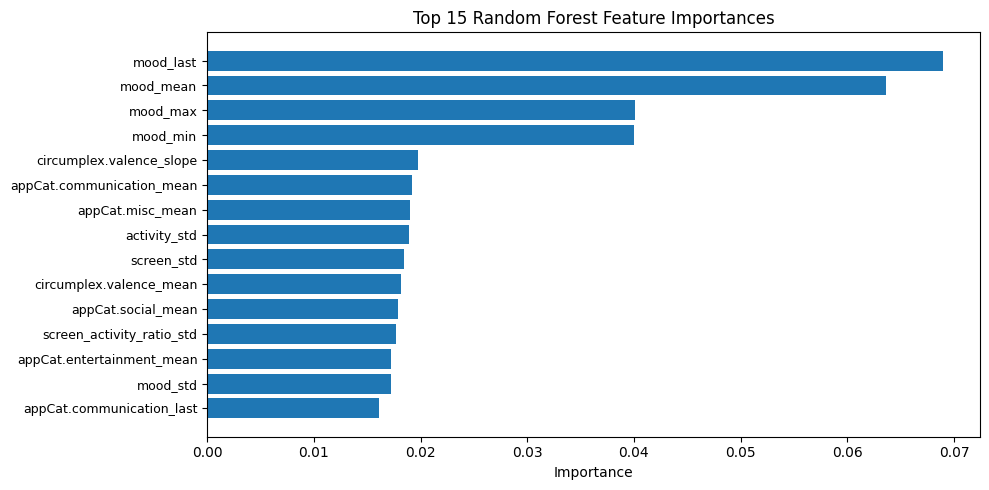

In [8]:
# Feature importance
best_rf = grid_search.best_estimator_
importances = best_rf.feature_importances_
feat_names = rf_feature_cols

# Top 15 features
sorted_idx = np.argsort(importances)[::-1][:15]

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(range(15), importances[sorted_idx][::-1])
ax.set_yticks(range(15))
ax.set_yticklabels([feat_names[i] for i in sorted_idx][::-1], fontsize=9)
ax.set_xlabel("Importance")
ax.set_title("Top 15 Random Forest Feature Importances")
plt.tight_layout()
plt.show()

In [9]:
# Testing if less is more
for n_features in [10, 20, 30]:
    top_idx = np.argsort(importances)[::-1][:n_features]
    X_train_top = X_rf_train[:, top_idx]
    X_test_top = X_rf_test[:, top_idx]
    
    rf_slim = RandomForestClassifier(
        **grid_search.best_params_, random_state=42
    )
    rf_slim.fit(X_train_top, y_train)
    y_pred = rf_slim.predict(X_test_top)
    
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    print(f"Top {n_features:2d} features: Accuracy={acc:.4f}, F1={f1:.4f}")

# Compare with full model
print(f"All {len(rf_feature_cols)} features: Accuracy={accuracy_score(y_test, y_pred_rf):.4f}, F1={f1_score(y_test, y_pred_rf):.4f}")

Top 10 features: Accuracy=0.7181, F1=0.6667
Top 20 features: Accuracy=0.7269, F1=0.6737
Top 30 features: Accuracy=0.7445, F1=0.6947
All 71 features: Accuracy=0.7577, F1=0.7090


So low importane featurs seem to contribute a useful signal.

In [10]:
# LSTM model

#TODO